In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    confusion_matrix,
    accuracy_score,
    classification_report,
    roc_curve
)

In [3]:
df = pd.read_csv("/content/train (1).csv")

print("Original data:")
print(df.head())

print("\nDataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

Original data:
   patient_id  age  gender blood_pressure  cholesterol   bmi diabetes  \
0           1   74   Other         130/72          240  31.5      Yes   
1           2   46  Female         120/92          292  36.3       No   
2           3   89   Other         135/78          153  30.3       No   
3           4   84  Female         123/80          153  31.5       No   
4           5   32   Other         135/84          205  18.4       No   

  hypertension  medication_count  length_of_stay discharge_destination  \
0           No                 5               1      Nursing_Facility   
1           No                 4               3      Nursing_Facility   
2          Yes                 1               1                  Home   
3          Yes                 3              10                  Home   
4          Yes                 6               4      Nursing_Facility   

  readmitted_30_days  
0                Yes  
1                 No  
2                 No  
3        

In [5]:
# Split blood pressure into systolic and diastolic BP
df[["systolic_bp", "diastolic_bp"]] = (
    df["blood_pressure"]
    .str.split("/", expand=True)
    .astype(float)
)

# Remove patient ID and original blood pressure column
df.drop(
    ["patient_id", "blood_pressure"],
    axis=1,
    inplace=True
)

# Convert Yes/No variables into 1/0
df["diabetes"] = df["diabetes"].map({
    "Yes": 1,
    "No": 0
})

df["hypertension"] = df["hypertension"].map({
    "Yes": 1,
    "No": 0
})

# Convert target variable into 1/0
df["readmitted_30_days"] = df["readmitted_30_days"].map({
    "Yes": 1,
    "No": 0
})

# Convert categorical variables into dummy variables
df = pd.get_dummies(
    df,
    columns=["gender", "discharge_destination"],
    drop_first=True
)

# Remove missing values
df = df.dropna()

print("\nData after preprocessing:")
print(df.head())

print("\nShape after preprocessing:", df.shape)



Data after preprocessing:
   age  cholesterol   bmi  diabetes  hypertension  medication_count  \
0   74          240  31.5         1             0                 5   
1   46          292  36.3         0             0                 4   
2   89          153  30.3         0             1                 1   
3   84          153  31.5         0             1                 3   
4   32          205  18.4         0             1                 6   

   length_of_stay  readmitted_30_days  systolic_bp  diastolic_bp  gender_Male  \
0               1                   1        130.0          72.0        False   
1               3                   0        120.0          92.0        False   
2               1                   0        135.0          78.0        False   
3              10                   0        123.0          80.0        False   
4               4                   0        135.0          84.0        False   

   gender_Other  discharge_destination_Nursing_Facility  \



Readmission distribution:
readmitted_30_days
0    26326
1     3674
Name: count, dtype: int64

Readmission percentages:
readmitted_30_days
0    87.753333
1    12.246667
Name: proportion, dtype: float64


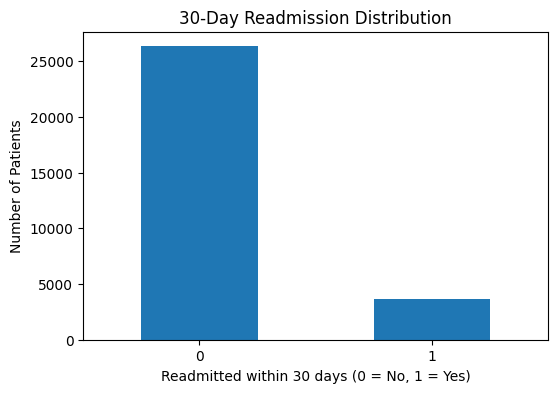

In [6]:
print("\nReadmission distribution:")
print(df["readmitted_30_days"].value_counts())

print("\nReadmission percentages:")
print(
    df["readmitted_30_days"]
    .value_counts(normalize=True) * 100
)

plt.figure(figsize=(6, 4))

df["readmitted_30_days"].value_counts().plot(
    kind="bar"
)

plt.xlabel("Readmitted within 30 days (0 = No, 1 = Yes)")
plt.ylabel("Number of Patients")
plt.title("30-Day Readmission Distribution")
plt.xticks(rotation=0)
plt.show()

In [7]:
X = df.drop(
    "readmitted_30_days",
    axis=1
)

y = df["readmitted_30_days"]

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining data:", X_train.shape)
print("Testing data:", X_test.shape)



Training data: (24000, 13)
Testing data: (6000, 13)


In [9]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)


In [10]:
model = LogisticRegression(
    penalty="l2",
    C=1.0,
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

# Train the model
model.fit(
    X_train_scaled,
    y_train
)

print("\nModel training completed.")
print(model)


Model training completed.
LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)


In [11]:
# Probability of 30-day readmission
y_prob = model.predict_proba(
    X_test_scaled
)[:, 1]

# Binary prediction using default threshold = 0.50
y_pred = model.predict(
    X_test_scaled
)


In [12]:
auc = roc_auc_score(
    y_test,
    y_prob
)

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("\n================ MODEL RESULTS ================")

print(f"ROC-AUC: {auc:.4f}")

print(f"Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Not Readmitted",
            "Readmitted"
        ]
    )
)


================ MODEL RESULTS ================
ROC-AUC: 0.5634
Accuracy: 0.6698

Classification Report:
                precision    recall  f1-score   support

Not Readmitted       0.89      0.71      0.79      5265
    Readmitted       0.16      0.40      0.23       735

      accuracy                           0.67      6000
     macro avg       0.53      0.55      0.51      6000
  weighted avg       0.80      0.67      0.72      6000




Confusion Matrix:
[[3723 1542]
 [ 439  296]]


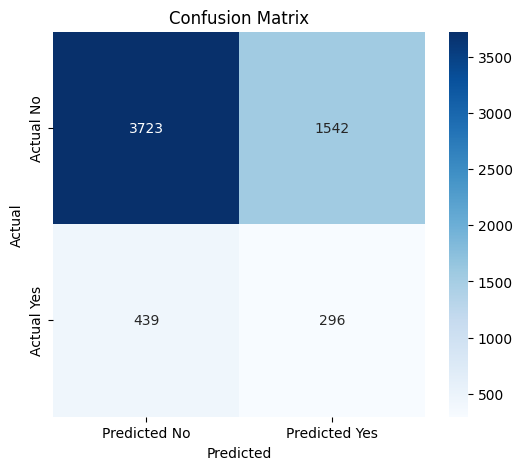

In [13]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Predicted No",
        "Predicted Yes"
    ],
    yticklabels=[
        "Actual No",
        "Actual Yes"
    ]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

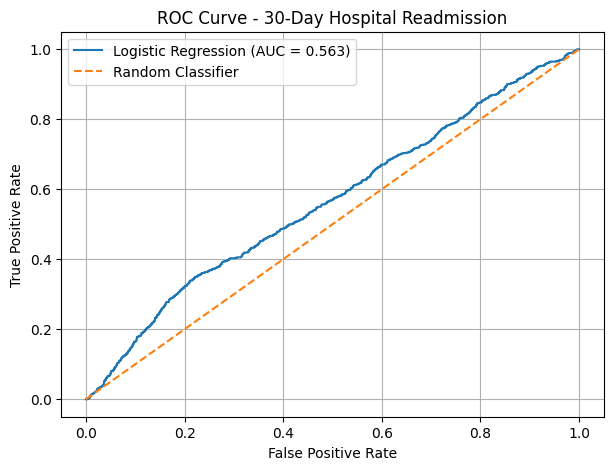

In [14]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - 30-Day Hospital Readmission")
plt.legend()
plt.grid(True)
plt.show()

In [15]:
tn, fp, fn, tp = cm.ravel()

print("\n================ CLINICAL ERROR ANALYSIS ================")

print(f"True Negatives  (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives  (TP): {tp}")

print("\nFalse Negatives:")
print(
    "Patients who were actually readmitted within 30 days "
    "but the model predicted they would NOT be readmitted."
)

print("\nFalse Positives:")
print(
    "Patients who were NOT readmitted within 30 days "
    "but the model predicted that they WOULD be readmitted."
)

print("\nClinical interpretation:")
print(
    "False negatives can be particularly costly because a high-risk "
    "patient may not receive additional monitoring, follow-up, or "
    "preventive intervention."
)

print(
    "False positives can also have costs because they may lead to "
    "additional monitoring, follow-up resources, or unnecessary "
    "clinical interventions."
)


================ CLINICAL ERROR ANALYSIS ================
True Negatives  (TN): 3723
False Positives (FP): 1542
False Negatives (FN): 439
True Positives  (TP): 296

False Negatives:
Patients who were actually readmitted within 30 days but the model predicted they would NOT be readmitted.

False Positives:
Patients who were NOT readmitted within 30 days but the model predicted that they WOULD be readmitted.

Clinical interpretation:
False negatives can be particularly costly because a high-risk patient may not receive additional monitoring, follow-up, or preventive intervention.
False positives can also have costs because they may lead to additional monitoring, follow-up resources, or unnecessary clinical interventions.


In [16]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

coefficients["Absolute_Coefficient"] = (
    coefficients["Coefficient"].abs()
)

coefficients = coefficients.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

print("\n================ FEATURE COEFFICIENTS ================")

print(
    coefficients[
        ["Feature", "Coefficient"]
    ].to_string(index=False)
)


================ FEATURE COEFFICIENTS ================
                               Feature  Coefficient
           discharge_destination_Rehab     0.269817
discharge_destination_Nursing_Facility     0.181667
                              diabetes     0.071717
                          hypertension     0.070524
                                   bmi    -0.039636
                           cholesterol     0.022518
                           systolic_bp    -0.015769
                          gender_Other     0.011291
                        length_of_stay    -0.006136
                      medication_count     0.006020
                           gender_Male    -0.004397
                                   age     0.004289
                          diastolic_bp     0.002258


In [17]:
coefficients["Odds_Ratio"] = np.exp(
    coefficients["Coefficient"]
)

print("\n================ ODDS RATIOS ================")

print(
    coefficients[
        ["Feature", "Coefficient", "Odds_Ratio"]
    ].to_string(index=False)
)


================ ODDS RATIOS ================
                               Feature  Coefficient  Odds_Ratio
           discharge_destination_Rehab     0.269817    1.309725
discharge_destination_Nursing_Facility     0.181667    1.199215
                              diabetes     0.071717    1.074352
                          hypertension     0.070524    1.073071
                                   bmi    -0.039636    0.961140
                           cholesterol     0.022518    1.022774
                           systolic_bp    -0.015769    0.984355
                          gender_Other     0.011291    1.011354
                        length_of_stay    -0.006136    0.993883
                      medication_count     0.006020    1.006038
                           gender_Male    -0.004397    0.995613
                                   age     0.004289    1.004298
                          diastolic_bp     0.002258    1.002261
